In [1]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 1: Read file, see the data, make sure that every thing right

In [3]:
df = pd.read_excel(r"D:/Final Project AKOMA Team/Data Clean.xlsx")

In [4]:
df.shape

(180519, 34)

In [5]:
df.head()

,Type of transaction,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Full name,...,Order Item Total,Benefit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,20755,Cally Holloway,...,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,19492,Irene Luna,...,311.359985,-249.089996,South Asia,Rajastán,PENDING,1360,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,19491,Gillian Maldonado,...,309.720001,-247.779999,South Asia,Rajastán,CLOSED,1360,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,19490,Tana Tate,...,304.809998,22.860001,Oceania,Queensland,COMPLETE,1360,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,19489,Orli Hendricks,...,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [6]:
df.columns

Index(['Type of transaction', 'Days for shipping (real)',
       'Days for shipment (scheduled)', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Full name', 'Customer Segment',
       'Customer State', 'Department Name', 'Market', 'Order City',
       'Order Country', 'order date (DateOrders)', 'Order Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id ',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Benefit Per Order', 'Order Region', 'Order State',
       'Order Status', 'Product Card Id', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='str')

STEP 2 — Data Types. make sure the coulmns have the right type 

In [7]:
df.dtypes

Type of transaction                         str
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Delivery Status                             str
Late_delivery_risk                        int64
Category Name                               str
Customer City                               str
Customer Country                            str
Customer Id                               int64
Full name                                   str
Customer Segment                            str
Customer State                              str
Department Name                             str
Market                                      str
Order City                                  str
Order Country                               str
order date (DateOrders)          datetime64[us]
Order Id                                  int64
Order Item Discount                     float64
Order Item Discount Rate                float64
Order Item Id                           

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type of transaction            180519 non-null  str           
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Delivery Status                180519 non-null  str           
 4   Late_delivery_risk             180519 non-null  int64         
 5   Category Name                  180519 non-null  str           
 6   Customer City                  180519 non-null  str           
 7   Customer Country               180519 non-null  str           
 8   Customer Id                    180519 non-null  int64         
 9   Full name                      180519 non-null  str           
 10  Customer Segment               180519 non-null  str           
 11  Customer St

In [9]:
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.astype(str),
    'Non_Null_Count': df.notna().sum().values,
    'Unique_Values': df.nunique().values
})

dtype_summary

,Column,Data_Type,Non_Null_Count,Unique_Values
Type of transaction,Type of transaction,str,180519,4
Days for shipping (real),Days for shipping (real),int64,180519,7
Days for shipment (scheduled),Days for shipment (scheduled),int64,180519,4
Delivery Status,Delivery Status,str,180519,4
Late_delivery_risk,Late_delivery_risk,int64,180519,2
Category Name,Category Name,str,180519,50
Customer City,Customer City,str,180519,563
Customer Country,Customer Country,str,180519,2
Customer Id,Customer Id,int64,180519,20652
Full name,Full name,str,180519,14033


STEP 3 — Missing Values

In [10]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().mean() * 100).round(2)
})

missing = missing.sort_values(
    'Missing_Count',
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
Type of transaction,0,0.0
Days for shipping (real),0,0.0
Days for shipment (scheduled),0,0.0
Delivery Status,0,0.0
Late_delivery_risk,0,0.0
Category Name,0,0.0
Customer City,0,0.0
Customer Country,0,0.0
Customer Id,0,0.0
Full name,0,0.0


In [11]:
missing[missing['Missing_Count'] > 0]

,Missing_Count,Missing_Percentage


STEP 4 — Duplicate Rows

In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [13]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head()

,Type of transaction,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Full name,...,Order Item Total,Benefit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode


STEP 5 — Unique Keys (primary Transaction Key)

In [14]:
# to remove speace from words
df.columns = df.columns.str.strip()

In [15]:
print("Order Item Id is unique:",
      df['Order Item Id'].is_unique)

Order Item Id is unique: True


In [16]:
print("Unique Order IDs:", df['Order Id'].nunique())
print("Unique Order Item IDs:", df['Order Item Id'].nunique())
print("Unique Customer IDs:", df['Customer Id'].nunique())
print("Unique Product IDs:", df['Product Card Id'].nunique())

Unique Order IDs: 65752
Unique Order Item IDs: 180519
Unique Customer IDs: 20652
Unique Product IDs: 118


In [17]:
print("Unique Order Item Id:",
      df['Order Item Id'].nunique())

print("Total Rows:",
      len(df))

Unique Order Item Id: 180519
Total Rows: 180519


STEP 6 — Cardinality / Number of Unique Values

In [18]:
cardinality = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': df.nunique()
})

cardinality.sort_values(
    'Unique_Count',
    ascending=False
)

,Column,Unique_Count
Order Item Id,Order Item Id,180519
Order Id,Order Id,65752
order date (DateOrders),order date (DateOrders),65752
shipping date (DateOrders),shipping date (DateOrders),63701
Benefit Per Order,Benefit Per Order,21998
Customer Id,Customer Id,20652
Full name,Full name,14033
Order City,Order City,3597
Order Item Total,Order Item Total,2927
Order State,Order State,1089


STEP 7 — Hidden Missing Values 

In [19]:
text_columns = df.select_dtypes(include='object').columns

hidden_missing = {}

for col in text_columns:
    values = df[col].astype(str).str.strip().str.lower()
    
    count = values.isin([
        '',
        'unknown',
        'n/a',
        'na',
        'null',
        'none'
    ]).sum()
    
    hidden_missing[col] = count

hidden_missing = pd.Series(hidden_missing).sort_values(
    ascending=False
)

hidden_missing

C:\Users\A-GF-L7-D15\AppData\Local\Temp\ipykernel_19580\3969303473.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns


Type of transaction    0
Delivery Status        0
Category Name          0
Customer City          0
Customer Country       0
Full name              0
Customer Segment       0
Customer State         0
Department Name        0
Market                 0
Order City             0
Order Country          0
Order Region           0
Order State            0
Order Status           0
Product Name           0
Shipping Mode          0
dtype: int64

STEP 8 — Negative & Invalid Values (from highlight numeric columns)

In [20]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

numeric_columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Late_delivery_risk', 'Customer Id', 'Order Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total', 'Benefit Per Order',
       'Product Card Id', 'Product Price'],
      dtype='str')

In [21]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.00000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00000,2.000000,4.000000,4.000000,4.000000
Late_delivery_risk,180519.0,0.548291,0.497664,0.00000,0.000000,1.000000,1.000000,1.000000
Customer Id,180519.0,6691.379495,4162.918106,1.00000,3258.500000,6457.000000,9779.000000,20757.000000
Order Id,180519.0,36221.894903,21045.379569,1.00000,18057.000000,36140.000000,54144.000000,77204.000000
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Id,180519.0,90260.000000,52111.490959,1.00000,45130.500000,90260.000000,135389.500000,180519.000000
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000


STEP 9 — Financial Fields

In [22]:
financial_columns = [
    'Sales',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Total',
    'Benefit Per Order',
    'Order Item Profit Ratio',
    'Product Price',
    'Order Item Quantity'
]
df[financial_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Total,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990
Benefit Per Order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000
Product Price,180519.0,141.232550,139.732492,9.99000,50.000000,59.990002,199.990005,1999.989990
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000


STEP 10 — Business Rule Checks (Sales,Discount,Quantity,Product Price,Shipping Days,Discount Rate)

In [23]:
print(
    "Negative Sales:",
    (df['Sales'] < 0).sum()
)

Negative Sales: 0


In [24]:
print(
    "Negative Discount:",
    (df['Order Item Discount'] < 0).sum()
)

Negative Discount: 0


In [25]:
print(
    "Non-positive Quantity:",
    (df['Order Item Quantity'] <= 0).sum()
)

Non-positive Quantity: 0


In [26]:
print(
    "Negative Product Price:",
    (df['Product Price'] < 0).sum()
)

Negative Product Price: 0


In [27]:
print(
    "Negative Real Shipping Days:",
    (df['Days for shipping (real)'] < 0).sum()
)

print(
    "Negative Scheduled Shipping Days:",
    (df['Days for shipment (scheduled)'] < 0).sum()
)

Negative Real Shipping Days: 0
Negative Scheduled Shipping Days: 0


In [28]:
print(
    "Discount Rate < 0:",
    (df['Order Item Discount Rate'] < 0).sum()
)

print(
    "Discount Rate > 1:",
    (df['Order Item Discount Rate'] > 1).sum()
)

Discount Rate < 0: 0
Discount Rate > 1: 0


STEP 11 — Negative Profit (count and voloum loss)

In [29]:
negative_profit = df[df['Benefit Per Order'] < 0]

print(
    "Negative Profit Rows:",
    len(negative_profit)
)

print(
    "Negative Profit Percentage:",
    round(len(negative_profit) / len(df) * 100, 2),
    "%"
)

Negative Profit Rows: 33784
Negative Profit Percentage: 18.71 %


In [30]:
negative_profit[
    [
        'Order Id',
        'Product Name',
        'Sales',
        'Order Item Discount',
        'Benefit Per Order',
        'Order Item Profit Ratio'
    ]
].head(10)

,Order Id,Product Name,Sales,Order Item Discount,Benefit Per Order,Order Item Profit Ratio
1,75939,Smart watch,327.750000,16.389999,-249.089996,-0.80
2,75938,Smart watch,327.750000,18.030001,-247.779999,-0.80
15,75925,Smart watch,327.750000,3.280000,-259.579987,-0.80
16,75924,Smart watch,327.750000,6.560000,-246.360001,-0.77
28,75912,Smart watch,327.750000,55.720001,-17.139999,-0.06
33,75907,Smart watch,327.750000,3.280000,-97.339996,-0.30
34,75906,Smart watch,327.750000,6.560000,-425.579987,-1.33
48,28744,Perfect Fitness Perfect Rip Deck,119.980003,4.800000,-30.750000,-0.27
49,45461,Under Armour Girls' Toddler Spine Surge Runni,79.980003,0.800000,-122.730003,-1.55
53,50054,Nike Men's Dri-FIT Victory Golf Polo,100.000000,13.000000,-21.750000,-0.25


STEP 12 — Date Consistency (order date (DateOrders) , shipping date (DateOrders))

In [31]:
print(df['order date (DateOrders)'].dtype)
print(df['shipping date (DateOrders)'].dtype)

datetime64[us]
datetime64[us]


In [32]:
df_check = df.copy()

df_check['order_date_parsed'] = pd.to_datetime(
    df_check['order date (DateOrders)'],
    errors='coerce'
)

df_check['shipping_date_parsed'] = pd.to_datetime(
    df_check['shipping date (DateOrders)'],
    errors='coerce'
)

In [33]:
print(
    "Invalid Order Dates:",
    df_check['order_date_parsed'].isna().sum()
)

print(
    "Invalid Shipping Dates:",
    df_check['shipping_date_parsed'].isna().sum()
)

Invalid Order Dates: 0
Invalid Shipping Dates: 0


In [34]:
print(
    "Minimum Order Date:",
    df_check['order_date_parsed'].min()
)

print(
    "Maximum Order Date:",
    df_check['order_date_parsed'].max()
)

Minimum Order Date: 2015-01-01 00:00:00
Maximum Order Date: 2018-01-31 23:38:00


STEP 13 — Shipping Date Logic (need to make sure that Shipping Date ≥ Order Date)

In [35]:
invalid_shipping_dates = df_check[
    df_check['shipping_date_parsed']
    <
    df_check['order_date_parsed']
]

print(
    "Shipping before Order:",
    len(invalid_shipping_dates)
)

Shipping before Order: 0


STEP 14 — Financial Formula Validation (we have Sales ,Discount ,Order Item Total ... and went to test (Sales − Discount ≈ Order Item Total))

In [36]:
df_check['sales_discount_difference'] = (
    df_check['Sales']
    - df_check['Order Item Discount']
    - df_check['Order Item Total']
)

In [37]:
print(
    "Maximum absolute difference:",
    df_check['sales_discount_difference'].abs().max()
)

Maximum absolute difference: 0.010013549999996485


In [38]:
formula_errors = df_check[
    df_check['sales_discount_difference'].abs() > 0.01
]

print(
    "Rows with significant formula difference:",
    len(formula_errors)
)

Rows with significant formula difference: 1224


STEP 15 — Profit Validation (Relationship between: Benefit Per Order,Order Item Profit Ratio,Sales,Order Item Total) (Validation:Profit Ratio = Benefit / Sales)

In [39]:
df[
    [
        'Sales',
        'Order Item Total',
        'Benefit Per Order',
        'Order Item Profit Ratio'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990
Order Item Total,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990
Benefit Per Order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000


In [40]:
df_check['calculated_profit_ratio'] = (
    df_check['Benefit Per Order']
    / df_check['Sales']
)

In [41]:
df_check['profit_ratio_difference'] = (
    df_check['calculated_profit_ratio']
    - df_check['Order Item Profit Ratio']
)
print(
    "Median Profit Ratio Difference:",
    df_check['profit_ratio_difference'].median()
)

print(
    "Maximum Absolute Difference:",
    df_check['profit_ratio_difference'].abs().max()
)

Median Profit Ratio Difference: -0.01448741980881274
Maximum Absolute Difference: 0.6874968765626641


STEP 16 — Outliers (to discaver strange orders)

In [42]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.00000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00000,2.000000,4.000000,4.000000,4.000000
Late_delivery_risk,180519.0,0.548291,0.497664,0.00000,0.000000,1.000000,1.000000,1.000000
Customer Id,180519.0,6691.379495,4162.918106,1.00000,3258.500000,6457.000000,9779.000000,20757.000000
Order Id,180519.0,36221.894903,21045.379569,1.00000,18057.000000,36140.000000,54144.000000,77204.000000
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Id,180519.0,90260.000000,52111.490959,1.00000,45130.500000,90260.000000,135389.500000,180519.000000
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000


In [43]:
outlier_summary = []

for col in numeric_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()
    
    outlier_summary.append({
        'Column': col,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Count': count,
        'Outlier_Percentage': round(
            count / len(df) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'Outlier_Count',
    ascending=False
)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
12,Benefit Per Order,-79.700005,151.500008,18942,10.49
8,Order Item Profit Ratio,-0.340000,0.780000,17300,9.58
5,Order Item Discount,-31.484999,66.874999,7537,4.18
14,Product Price,-174.985008,424.975014,2048,1.13
11,Order Item Total,-110.149998,461.929989,1943,1.08
3,Customer Id,-6522.250000,19559.750000,1198,0.66
10,Sales,-149.975010,569.905025,488,0.27
6,Order Item Discount Rate,-0.140000,0.340000,0,0.00
4,Order Id,-36073.500000,108274.500000,0,0.00
1,Days for shipment (scheduled),-1.000000,7.000000,0,0.00


STEP 18 — Boxplots (financial variables: like: Long tails,Negative profit extremes, large value)

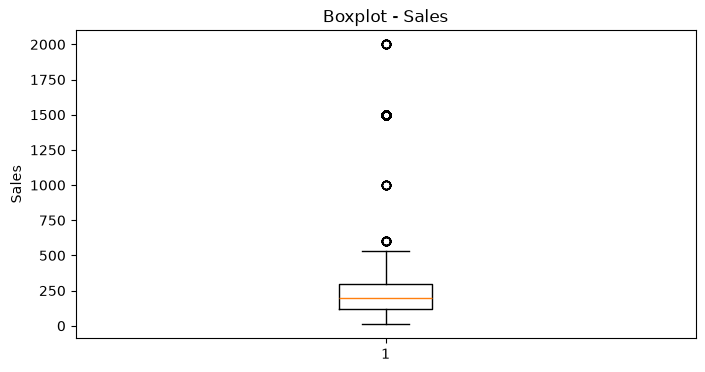

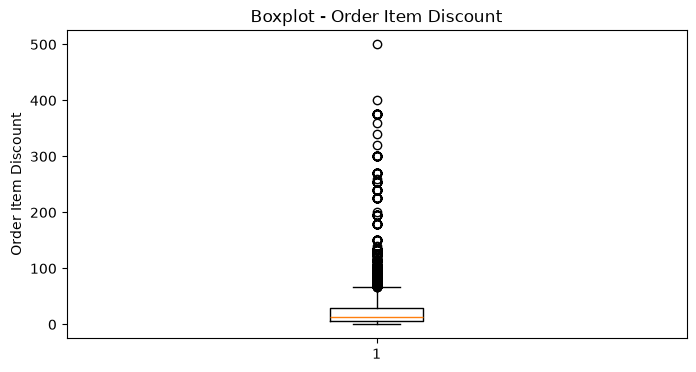

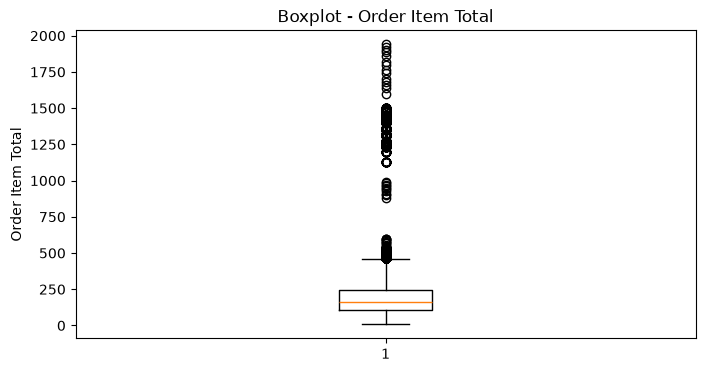

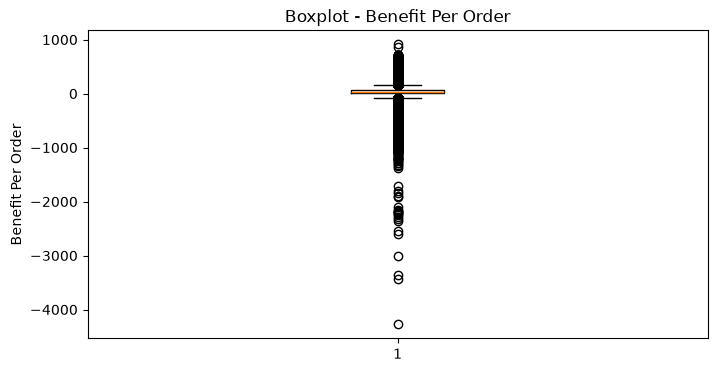

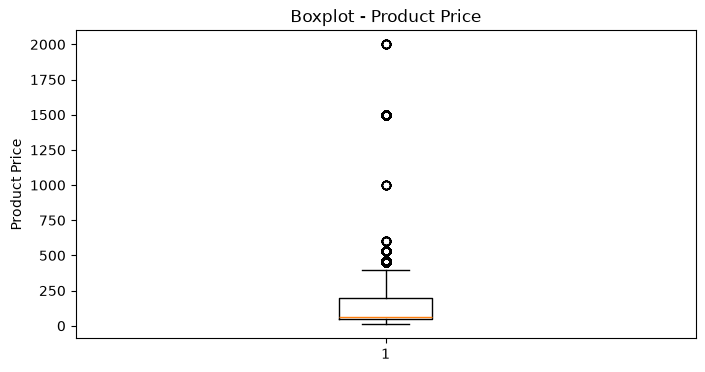

In [44]:
financial_plot_columns = [
    'Sales',
    'Order Item Discount',
    'Order Item Total',
    'Benefit Per Order',
    'Product Price'
]

for col in financial_plot_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot - {col}')
    plt.ylabel(col)
    plt.show()

STEP 19 — Target Distribution (from: Late_delivery_risk; test the best ML can use)

In [45]:
target_counts = df['Late_delivery_risk'].value_counts()

target_counts

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [46]:
target_distribution = pd.DataFrame({
    'Count': df['Late_delivery_risk'].value_counts(),
    'Percentage': (
        df['Late_delivery_risk']
        .value_counts(normalize=True) * 100
    ).round(2)
})

target_distribution

,Count,Percentage
Late_delivery_risk,,
1,98977,54.83
0,81542,45.17


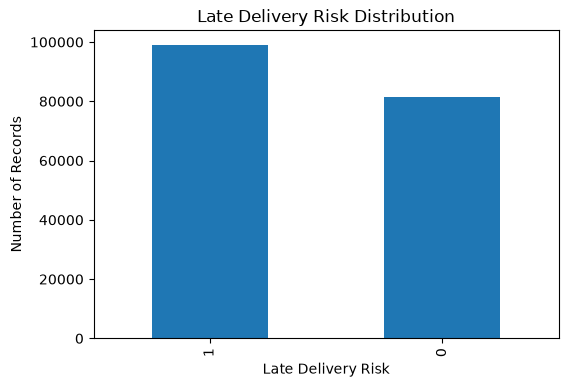

In [47]:
df['Late_delivery_risk'].value_counts().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Late Delivery Risk Distribution')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Number of Records')
plt.show()

STEP 20 — ML Leakage Candidates (does orders will late; know diffrent between Available Before Outcome & Available After Outcome)

In [48]:
potential_leakage_columns = [
    'Days for shipping (real)',
    'Delivery Status',
    'shipping date (DateOrders)'
]

potential_leakage_columns

['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)']

STEP 21 — Profit Leakage Analysis (High Sales,Low Profit Margin)

In [49]:
high_sales_threshold = df['Sales'].quantile(0.80)
low_margin_threshold = df['Order Item Profit Ratio'].quantile(0.20)

profit_leakage_candidates = df[
    (df['Sales'] >= high_sales_threshold) &
    (df['Order Item Profit Ratio'] <= low_margin_threshold)
]

In [50]:
print(
    "Profit Leakage Candidate Rows:",
    len(profit_leakage_candidates)
)

Profit Leakage Candidate Rows: 8007


In [51]:
profit_leakage_candidates[
    [
        'Product Name',
        'Category Name',
        'Department Name',
        'Market',
        'Order Region',
        'Sales',
        'Order Item Discount',
        'Order Item Profit Ratio',
        'Benefit Per Order'
    ]
].head(20)

,Product Name,Category Name,Department Name,Market,Order Region,Sales,Order Item Discount,Order Item Profit Ratio,Benefit Per Order
1,Smart watch,Sporting Goods,Fitness,Pacific Asia,South Asia,327.750000,16.389999,-0.80,-249.089996
2,Smart watch,Sporting Goods,Fitness,Pacific Asia,South Asia,327.750000,18.030001,-0.80,-247.779999
15,Smart watch,Sporting Goods,Fitness,Pacific Asia,South Asia,327.750000,3.280000,-0.80,-259.579987
16,Smart watch,Sporting Goods,Fitness,Pacific Asia,Eastern Asia,327.750000,6.560000,-0.77,-246.360001
28,Smart watch,Sporting Goods,Fitness,Pacific Asia,Eastern Asia,327.750000,55.720001,-0.06,-17.139999
33,Smart watch,Sporting Goods,Fitness,Pacific Asia,Eastern Asia,327.750000,3.280000,-0.30,-97.339996
34,Smart watch,Sporting Goods,Fitness,Pacific Asia,Eastern Asia,327.750000,6.560000,-1.33,-425.579987
47,Smart watch,Sporting Goods,Fitness,Pacific Asia,Eastern Asia,327.750000,59.000000,0.00,0.000000
117,Polar FT4 Heart Rate Monitor,Kids' Golf Clubs,Outdoors,LATAM,Central America,449.950012,53.990002,-0.20,-79.190002
121,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,Footwear,LATAM,Central America,499.950012,5.000000,-0.04,-18.809999


STEP 22 — Discount Effectiveness Candidates (we will need it for analysis) & (prepare for EDA)

In [52]:
df['Order Item Discount Rate'].describe()

count    180519.000000
mean          0.101668
std           0.070415
min           0.000000
25%           0.040000
50%           0.100000
75%           0.160000
max           0.250000
Name: Order Item Discount Rate, dtype: float64

In [53]:
df.groupby(
    'Order Item Discount Rate'
).agg(
    Orders=('Order Id', 'nunique'),
    Items=('Order Item Id', 'count'),
    Quantity=('Order Item Quantity', 'sum'),
    Sales=('Sales', 'sum'),
    Total_Value=('Order Item Total', 'sum'),
    Benefit=('Benefit Per Order', 'sum'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).reset_index()

,Order Item Discount Rate,Orders,Items,Quantity,Sales,Total_Value,Benefit,Avg_Profit_Ratio
0,0.00,9400,10028,21367,2.042369e+06,2.042369e+06,267412.402338,0.127455
1,0.01,9356,10028,21329,2.042793e+06,2.022363e+06,238653.961066,0.121483
2,0.02,9364,10028,21339,2.042818e+06,2.001958e+06,237401.160814,0.122657
3,0.03,9403,10029,21329,2.043344e+06,1.982037e+06,222475.430184,0.110835
4,0.04,9364,10029,21336,2.043378e+06,1.961634e+06,234683.300468,0.123555
5,0.05,9366,10029,21343,2.043413e+06,1.941234e+06,238468.229398,0.126502
6,0.06,9376,10029,21333,2.043421e+06,1.931024e+06,241415.970777,0.124464
7,0.07,9384,10029,21343,2.043452e+06,1.900399e+06,233404.920995,0.124016
8,0.09,9385,10029,21321,2.043478e+06,1.859552e+06,229769.420426,0.122824
9,0.10,9377,10029,21338,2.043501e+06,1.839142e+06,221921.319172,0.119368


STEP 23 — Business Rule: Late Delivery (Days for shipping (real) ,Days for shipment (scheduled))

In [54]:
df_check['shipping_delay_days'] = (
    df_check['Days for shipping (real)']
    -
    df_check['Days for shipment (scheduled)']
)

df_check['shipping_delay_days'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: shipping_delay_days, dtype: float64

In [55]:
print(
    "Negative Delay:",
    (df_check['shipping_delay_days'] < 0).sum()
)

Negative Delay: 43366


STEP 24 — Final Data Quality Summary 

In [56]:
quality_summary = {
    'Rows': len(df),
    'Columns': len(df.columns),
    'Duplicate_Rows': df.duplicated().sum(),
    'Missing_Values': df.isnull().sum().sum(),
    'Unique_Order_Item_ID': df['Order Item Id'].nunique(),
    'Unique_Orders': df['Order Id'].nunique(),
    'Negative_Sales': (df['Sales'] < 0).sum(),
    'Negative_Discount': (df['Order Item Discount'] < 0).sum(),
    'Negative_Profit': (df['Benefit Per Order'] < 0).sum(),
    'Invalid_Order_Dates': df_check['order_date_parsed'].isna().sum(),
    'Invalid_Shipping_Dates': df_check['shipping_date_parsed'].isna().sum(),
    'Shipping_Before_Order': len(invalid_shipping_dates),
    'Financial_Formula_Errors': len(formula_errors)
}

quality_summary

{'Rows': 180519,
 'Columns': 34,
 'Duplicate_Rows': np.int64(0),
 'Missing_Values': np.int64(0),
 'Unique_Order_Item_ID': 180519,
 'Unique_Orders': 65752,
 'Negative_Sales': np.int64(0),
 'Negative_Discount': np.int64(0),
 'Negative_Profit': np.int64(33784),
 'Invalid_Order_Dates': np.int64(0),
 'Invalid_Shipping_Dates': np.int64(0),
 'Shipping_Before_Order': 0,
 'Financial_Formula_Errors': 1224}

In [57]:
quality_report = pd.DataFrame(
    quality_summary.items(),
    columns=['Check', 'Result']
)

quality_report

,Check,Result
0,Rows,180519
1,Columns,34
2,Duplicate_Rows,0
3,Missing_Values,0
4,Unique_Order_Item_ID,180519
5,Unique_Orders,65752
6,Negative_Sales,0
7,Negative_Discount,0
8,Negative_Profit,33784
9,Invalid_Order_Dates,0


STEP 25 — Business Logic Validation (make sure about defination of Profit Ratio) (Profit Ratio ≈ Benefit / Order Item Total)

In [58]:
df_check['calculated_profit_ratio_total'] = (
    df_check['Benefit Per Order'] /
    df_check['Order Item Total']
)

df_check['profit_ratio_total_difference'] = (
    df_check['calculated_profit_ratio_total']
    - df_check['Order Item Profit Ratio']
)

print(
    "Median Difference:",
    df_check['profit_ratio_total_difference'].median()
)

print(
    "Maximum Absolute Difference:",
    df_check['profit_ratio_total_difference'].abs().max()
)

Median Difference: 1.393939380589515e-09
Maximum Absolute Difference: 0.005505314633127034


TEP 26 — Discount Business Logic (makke sure: Discount ≤ Sales, Discount Rate ≈ Discount / Sales)

In [59]:
df_check['calculated_discount_rate'] = (
    df_check['Order Item Discount'] /
    df_check['Sales']
)

df_check['discount_rate_difference'] = (
    df_check['calculated_discount_rate']
    - df_check['Order Item Discount Rate']
)

print(
    "Maximum Discount Rate Difference:",
    df_check['discount_rate_difference'].abs().max()
)

print(
    "Rows where Discount > Sales:",
    (df_check['Order Item Discount'] > df_check['Sales']).sum()
)

Maximum Discount Rate Difference: 0.005407278273508759
Rows where Discount > Sales: 0


STEP 27 — Shipping Logic (already have Negative Delay = 43,366 becouse; Actual Days < Scheduled Days) (الطلب وصل أسرع من المتوقع)

In [60]:
df_check['shipping_delay_days'] = (
    df_check['Days for shipping (real)']
    - df_check['Days for shipment (scheduled)']
)

print(
    df_check['shipping_delay_days']
    .value_counts()
    .sort_index()
)

shipping_delay_days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64


In [61]:
#know Shipping Delay Days
print(
    "Early shipments:",
    (df_check['shipping_delay_days'] < 0).sum()
)

print(
    "On-time shipments:",
    (df_check['shipping_delay_days'] == 0).sum()
)

print(
    "Late shipments:",
    (df_check['shipping_delay_days'] > 0).sum()
)

Early shipments: 43366
On-time shipments: 33753
Late shipments: 103400


STEP 28 — Relationship between Delay & late Risk (هل Late_delivery_risk منطقي ومتسق مع الـShipping information؟)

In [62]:
pd.crosstab(
    df_check['shipping_delay_days'],
    df_check['Late_delivery_risk'],
    normalize='index'
).round(3)

Late_delivery_risk,0,1
shipping_delay_days,,
-2,1.000,0.000
-1,1.000,0.000
0,1.000,0.000
1,0.044,0.956
2,0.041,0.959
3,0.040,0.960
4,0.041,0.959


In [63]:
pd.crosstab(
    df_check['Delivery Status'],
    df_check['Late_delivery_risk'],
    normalize='index'
).round(3)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,1.0,0.0
Late delivery,0.0,1.0
Shipping canceled,1.0,0.0
Shipping on time,1.0,0.0


STEP 29 — Order-Level Structure (Order ≠ Order Item) (نريد معرفة توزيع عدد المنتجات داخل كل Order.)

In [64]:
order_items = (
    df.groupby('Order Id')['Order Item Id']
    .count()
)

order_items.describe()

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Order Item Id, dtype: float64

In [65]:
print(
    "Orders with more than one item:",
    (order_items > 1).sum()
)

print(
    "Maximum items in one order:",
    order_items.max()
)

Orders with more than one item: 45902
Maximum items in one order: 5


STEP 30 — Customer-Level Structure 

In [66]:
customer_summary = (
    df.groupby('Customer Id')
    .agg(
        Orders=('Order Id', 'nunique'),
        Items=('Order Item Id', 'count'),
        Sales=('Sales', 'sum'),
        Profit=('Benefit Per Order', 'sum'),
        Discount=('Order Item Discount', 'sum')
    )
    .reset_index()
)

customer_summary.describe()

,Customer Id,Orders,Items,Sales,Profit,Discount
count,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000
mean,10400.285929,3.183808,8.740994,1781.170589,192.083235,180.630370
std,5993.106225,2.430699,8.375895,1677.328081,389.131248,177.834134
min,1.000000,1.000000,1.000000,11.290000,-3868.559982,0.000000
25%,5208.750000,1.000000,1.000000,293.040008,5.427500,22.600000
50%,10407.500000,3.000000,7.000000,1499.825033,109.830002,133.149994
75%,15594.250000,5.000000,15.000000,2915.880065,397.967494,295.192500
max,20757.000000,15.000000,47.000000,10524.170178,2441.970003,1203.630003


STEP 31 — Product-Level Structure (use later in Product Profit Leakage)

In [67]:
product_summary = (
    df.groupby(
        ['Product Card Id', 'Product Name']
    )
    .agg(
        Items=('Order Item Id', 'count'),
        Orders=('Order Id', 'nunique'),
        Quantity=('Order Item Quantity', 'sum'),
        Sales=('Sales', 'sum'),
        Profit=('Benefit Per Order', 'sum'),
        Discount=('Order Item Discount', 'sum')
    )
    .reset_index()
)

product_summary['Profit_Margin'] = (
    product_summary['Profit']
    / product_summary['Sales']
)

STEP 32 — Final Business Data Profile 

In [68]:
business_profile = pd.DataFrame({
    'Metric': [
        'Rows',
        'Orders',
        'Customers',
        'Products',
        'Markets',
        'Countries',
        'Categories',
        'Negative Profit Items',
        'Late Risk Items'
    ],
    'Value': [
        len(df),
        df['Order Id'].nunique(),
        df['Customer Id'].nunique(),
        df['Product Card Id'].nunique(),
        df['Market'].nunique(),
        df['Order Country'].nunique(),
        df['Category Name'].nunique(),
        (df['Benefit Per Order'] < 0).sum(),
        (df['Late_delivery_risk'] == 1).sum()
    ]
})

business_profile

,Metric,Value
0,Rows,180519
1,Orders,65752
2,Customers,20652
3,Products,118
4,Markets,5
5,Countries,164
6,Categories,50
7,Negative Profit Items,33784
8,Late Risk Items,98977


CHECK 1 — Financial Errors (1224 rows) Investigate Financial Formula Errors

We investigate the 1,224 records that did not satisfy the expected
Sales - Discount ≈ Order Item Total relationship.

The goal is to determine whether these are genuine data errors,
rounding differences, or differences in the business definition of the fields,
 CHECK 3 Negative Profit

In [69]:
df_check = df.copy()

df_check['formula_difference'] = (
    df_check['Sales']
    - df_check['Order Item Discount']
    - df_check['Order Item Total']
)
formula_errors = df_check[
    df_check['formula_difference'].abs() > 0.01
].copy()

In [70]:
formula_errors = df_check[
    df_check['formula_difference'].abs() > 0.01
].copy()

formula_errors[
    [
        'Sales',
        'Order Item Discount',
        'Order Item Total',
        'formula_difference'
    ]
].head(20)

,Sales,Order Item Discount,Order Item Total,formula_difference
5,327.75,32.779999,294.980011,-0.010010
11,327.75,59.000000,268.760010,-0.010010
16,327.75,6.560000,321.200012,-0.010012
23,327.75,32.779999,294.980011,-0.010010
29,327.75,59.000000,268.760010,-0.010010
34,327.75,6.560000,321.200012,-0.010012
41,327.75,32.779999,294.980011,-0.010010
47,327.75,59.000000,268.760010,-0.010010
366,327.75,6.560000,321.200012,-0.010012
373,327.75,32.779999,294.980011,-0.010010


In [71]:
formula_errors['formula_difference'].describe()

count    1224.000000
mean       -0.010006
std         0.000004
min        -0.010014
25%        -0.010010
50%        -0.010006
75%        -0.010002
max        -0.010000
Name: formula_difference, dtype: float64

In [72]:
print("Number of formula errors:", len(formula_errors))

print(
    "Maximum absolute difference:",
    formula_errors['formula_difference'].abs().max()
)

print(
    "Median absolute difference:",
    formula_errors['formula_difference'].abs().median()
)

Number of formula errors: 1224
Maximum absolute difference: 0.010013549999996485
Median absolute difference: 0.010005980000016734


In [73]:
formula_errors[
    formula_errors['formula_difference'].abs() > 1
][
    [
        'Sales',
        'Order Item Discount',
        'Order Item Total',
        'formula_difference'
    ]
].head(20)

,Sales,Order Item Discount,Order Item Total,formula_difference


In [ ]:
# التاكد من ان مشكلة 1224 الصف هيا فروق نسبة وليس اخطاء 
print(
    "Rows with difference > 0.011:",
    (df_check['formula_difference'].abs() > 0.011).sum()
)

Rows with difference > 0.011: 0


In [75]:
profit_check = (
    df_check['Sales']
    - df_check['Order Item Discount']
    - df_check['Benefit Per Order']
)

In [76]:
negative_profit = df[
    df['Benefit Per Order'] < 0
]

negative_profit[['Sales',
                 'Order Item Discount',
                 'Benefit Per Order',
                 'Order Item Profit Ratio']].describe()

,Sales,Order Item Discount,Benefit Per Order,Order Item Profit Ratio
count,33784.000000,33784.000000,33784.000000,33784.000000
mean,203.355791,20.725784,-114.952266,-0.625031
std,130.196316,21.635271,160.279465,0.626956
min,9.990000,0.000000,-4274.979980,-2.750000
25%,119.980003,5.500000,-149.389999,-0.800000
50%,199.919998,14.400000,-57.369999,-0.380000
75%,299.950012,30.000000,-20.575000,-0.170000
max,1999.989990,375.000000,-0.130000,-0.010000


In [77]:
negative_profit['Category Name'].value_counts().head(10)

Category Name
Cleats                  4590
Men's Footwear          4169
Women's Apparel         3923
Indoor/Outdoor Games    3617
Fishing                 3209
Water Sports            2924
Camping & Hiking        2590
Cardio Equipment        2332
Shop By Sport           2154
Electronics              562
Name: count, dtype: int64

In [78]:
negative_profit['Market'].value_counts()

Market
LATAM           9588
Europe          9420
Pacific Asia    7806
USCA            4812
Africa          2158
Name: count, dtype: int64

In [81]:
df.to_csv("final_cleaned_data.csv", index=False)